In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
import random

In [2]:
nvda = yf.download(
    "NVDA",
    start="2000-01-01",
    end="2026-01-01",
    progress=False
)

returns = np.log(nvda["Close"]).diff().dropna()

print("Price observations:", len(nvda))
print("Return observations:", len(returns))

Price observations: 6539
Return observations: 6538


In [3]:
returns = pd.read_csv("../data/processed/nvda_log_returns_2000_2026.csv", index_col=0)

X = returns.values.reshape(-1,1)

print("Observations:", len(X))

Observations: 6538


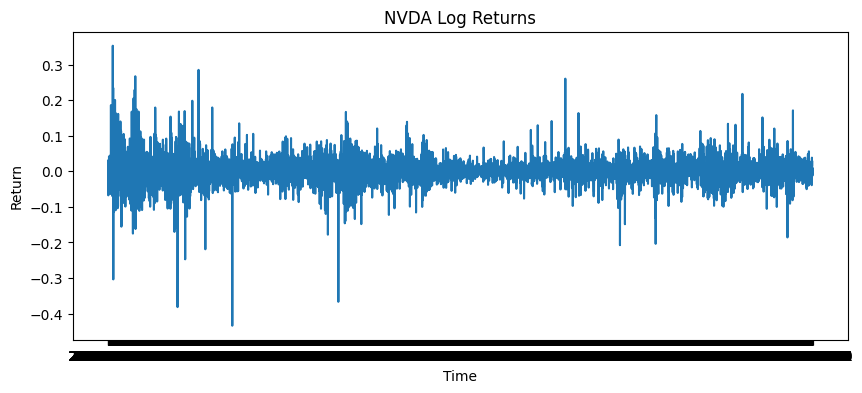

In [4]:
plt.figure(figsize=(10,4))
plt.plot(returns)
plt.title("NVDA Log Returns")
plt.xlabel("Time")
plt.ylabel("Return")
plt.show()

The plot shows the daily log returns of NVDA over the sample period. The Returns fluctuate around zero, which is expected since log returns remove long-term price trends and center the series near their mean.

Importantly, the strength of fluctation varies over time, indicating periods of higher and lower volatility. This suggests the presence of time-varying volatility regimes, which motivates my use of a Hidden Markov Model (HMM). In hopes to capture the underlying distributions governing market behavior.

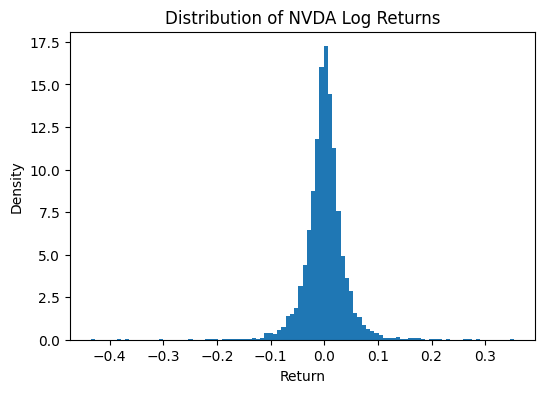

In [5]:
plt.figure(figsize=(6,4))
plt.hist(returns, bins=100, density=True)
plt.title("Distribution of NVDA Log Returns")
plt.xlabel("Return")
plt.ylabel("Density")
plt.show()

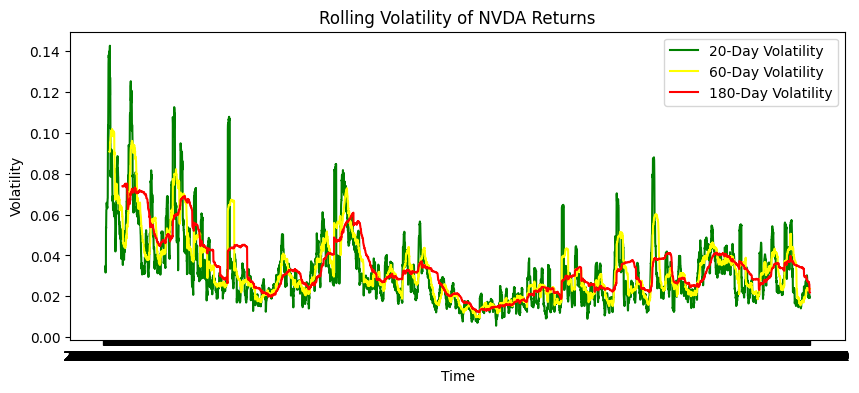

In [6]:
rolling_vol_30 = returns.rolling(20).std()
rolling_vol_50 = returns.rolling(60).std()
rolling_vol_100 = returns.rolling(180).std()

plt.figure(figsize=(10,4))

plt.plot(rolling_vol_30, label="20-Day Volatility", color="green")
plt.plot(rolling_vol_50, label="60-Day Volatility", color="yellow")
plt.plot(rolling_vol_100, label="180-Day Volatility", color="red")

plt.title("Rolling Volatility of NVDA Returns")
plt.xlabel("Time")
plt.ylabel("Volatility")

plt.legend()
plt.show()

Looks cool, could have some cool explanation 

In [7]:
results = []
best_models = {}

for K in range(1,6):

    scores = []
    models = []

    print("\nTesting K =", K)

    for i in range(20):

        ran_state = random.randint(1,10000)

        model = GaussianHMM(
            n_components=K,
            covariance_type="diag",
            n_iter=2000,
            tol=1e-3,
            random_state=ran_state
        )

        model.fit(X)

        score = model.score(X)

        scores.append(score)
        models.append(model)


    best_idx = np.argmax(scores)
    best_model = models[best_idx]
    best_score = scores[best_idx]

    worst_score = min(scores)
    diff = best_score - worst_score

    print("Best score:", best_score)
    print("Worst score:", worst_score)
    print("Difference:", diff)

    best_models[K] = best_model

    results.append({
        "K":K,
        "best_logL":best_score,
        "worst_logL":worst_score,
        "diff":diff
    })


Testing K = 1
Best score: 12264.89304804902
Worst score: 12264.89304804902
Difference: 0.0

Testing K = 2


Model is not converging.  Current: 13421.573604877896 is not greater than 13421.57380772296. Delta is -0.00020284506354073528


Best score: 13421.57225027906
Worst score: 13421.555390038886
Difference: 0.01686024017362797

Testing K = 3


Model is not converging.  Current: 13626.123923395971 is not greater than 13626.126394236151. Delta is -0.002470840179739753
Model is not converging.  Current: 13627.656997730202 is not greater than 13627.66316027466. Delta is -0.006162544457765762
Model is not converging.  Current: 13627.817677924038 is not greater than 13627.819913896295. Delta is -0.0022359722570399754
Model is not converging.  Current: 13626.059659954222 is not greater than 13626.062410479664. Delta is -0.0027505254420248093
Model is not converging.  Current: 13626.133521519221 is not greater than 13626.13484893166. Delta is -0.0013274124394229148
Model is not converging.  Current: 13626.120209068591 is not greater than 13626.120825937685. Delta is -0.0006168690943013644
Model is not converging.  Current: 13627.853187420485 is not greater than 13627.856284768137. Delta is -0.0030973476514191134
Model is not converging.  Current: 13626.130858644237 is not greater than 13626.13270964075. Delta is -0.00185099651207565

Best score: 13627.845565811525
Worst score: 13626.05087084264
Difference: 1.794694968884869

Testing K = 4


Model is not converging.  Current: 13698.739084714645 is not greater than 13698.739371485806. Delta is -0.00028677116097242106
Model is not converging.  Current: 13688.974564318334 is not greater than 13688.974582261262. Delta is -1.794292802514974e-05
Model is not converging.  Current: 13635.262623853037 is not greater than 13635.263163663232. Delta is -0.000539810194823076
Model is not converging.  Current: 13641.289436524174 is not greater than 13641.29177649446. Delta is -0.002339970285902382
Model is not converging.  Current: 13641.911008632627 is not greater than 13641.919384275341. Delta is -0.008375642713872367
Model is not converging.  Current: 13639.790686791293 is not greater than 13639.796132595086. Delta is -0.005445803792099468
Model is not converging.  Current: 13642.407618979754 is not greater than 13642.41476235446. Delta is -0.00714337470526516


Best score: 13699.515313697299
Worst score: 13635.256417997469
Difference: 64.25889569982974

Testing K = 5
Best score: 13766.586640671876
Worst score: 13690.368695894505
Difference: 76.21794477737058


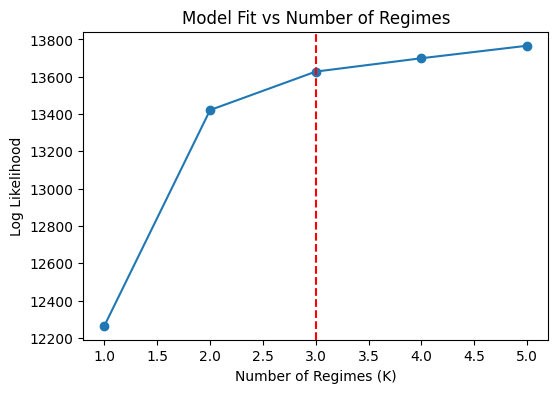

In [8]:
Ks = [r["K"] for r in results]
scores = [r["best_logL"] for r in results]

plt.figure(figsize=(6,4))
plt.plot(Ks, scores, marker="o")
plt.xlabel("Number of Regimes (K)")
plt.ylabel("Log Likelihood")
plt.title("Model Fit vs Number of Regimes")
plt.axvline(x=3, color="red", linestyle="--", label="Chosen K=3")
plt.show()

The plot shows the log-likelihood of the Hidden Markov Model as a function of the number of regimes K. As expected, the log-likelihood increases as additional regimes are introduced, since a more flexible model can better capture more structure in the data.

However, the marginal improvement in log-likelihood begins to diminish after K = 3. The sharp increase from K=1 to K=2 and the continued improvement at K=3 indicate that multiple volatility regimes are present in the return series. Beyond this point, the gains in model fit become relatively small. I believe this suggest that additional regimes primarily capture noise rather than meaningful structure.

The dashed vertical line highlights K=3 as the selected model (# of regimes). 

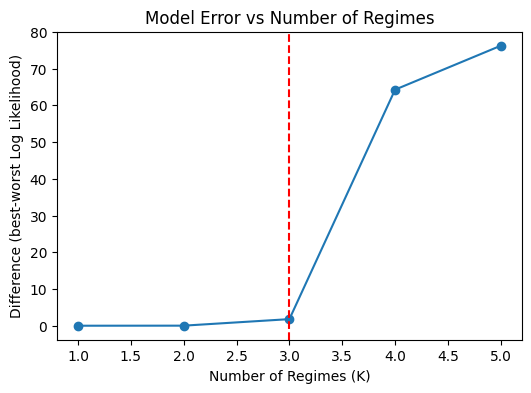

In [16]:
Ks = [r["K"] for r in results]
diff = [r["diff"] for r in results]

plt.figure(figsize=(6,4))
plt.plot(Ks, diff, marker="o")
plt.xlabel("Number of Regimes (K)")
plt.ylabel("Difference (best-worst Log Likelihood)")
plt.title("Model Error vs Number of Regimes")
plt.axvline(x=3, color="red", linestyle="--", label="Chosen K=3")
plt.show()

This visualization shows that K=3 is more than just best fit based on log likehood. But it's also a strong canddidate for the 20 iterations of model fitting that regular agreed on the confident of the log likelhood.

In [9]:
K = 3

model = best_models[K]

print("Final Model Score:", model.score(X))
print("Converged:", model.monitor_.converged)

Final Model Score: 13627.845565811525
Converged: True


Now that we have fit our data on the model with 3 regimes. Hopefully, we may also caputre different techniques to predict and how the prediction looks overall.